In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    precision_score,
    f1_score,
    roc_auc_score,
    log_loss,
    recall_score,
    
)
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder

In [2]:
df = pd.read_csv("../data/Telc_customer_churn_cleaned.csv")


In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Average Monthly Spend,Multiple Services
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,54.075000,True
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,75.825000,False
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,102.562500,True
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,108.787500,True
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,102.781633,True


In [4]:
df['Contract'].unique() 

<StringArray>
['Month-to-month', 'Two year', 'One year']
Length: 3, dtype: str

In [5]:
encode_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 
                   'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
                   'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
                   'Paperless Billing', 'Payment Method', 'Multiple Services']

X = df.drop(columns=['Churn Value', 'Churn Label', 'Churn Reason', 'CustomerID',
                             'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long',
                             'Latitude', 'Longitude', 'CLTV'])
y = df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = ['Monthly Charges', 'Total Charges', 'Average Monthly Spend', 
                    'Tenure Months']

contract_order = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}

X_train['Contract'] = X['Contract'].map(contract_order)
X_test['Contract'] = X['Contract'].map(contract_order)

te = TargetEncoder(cols=encode_cols)
X_train_encoded = te.fit_transform(X_train, y_train)
X_test_encoded = te.transform(X_test)

ct = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'
)

X_train_scaled = ct.fit_transform(X_train_encoded)
X_test_scaled = ct.transform(X_test_encoded)


In [6]:
X_train

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Score,Average Monthly Spend,Multiple Services
2902,Male,No,Yes,Yes,65,Yes,Yes,Fiber optic,Yes,Yes,...,No,No,2,No,Credit card (automatic),94.55,6078.75,36,93.519231,True
7003,Male,No,No,No,26,No,No phone service,DSL,No,No,...,No,No,0,No,Electronic check,35.75,1022.50,65,39.326923,True
4340,Female,No,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,...,No,No,2,No,Credit card (automatic),90.20,6297.65,55,92.612500,True
5178,Male,No,No,No,3,Yes,No,Fiber optic,No,Yes,...,No,Yes,0,No,Electronic check,84.30,235.05,43,78.350000,True
4479,Female,No,Yes,No,49,No,No phone service,DSL,Yes,No,...,Yes,No,0,No,Bank transfer (automatic),40.65,2070.75,29,42.260204,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4411,Male,Yes,Yes,No,65,Yes,No,Fiber optic,No,No,...,No,No,1,Yes,Bank transfer (automatic),70.95,4555.20,30,70.080000,False
1345,Female,Yes,No,No,15,Yes,No,Fiber optic,No,Yes,...,No,No,0,Yes,Credit card (automatic),75.30,1147.45,99,76.496667,True
4910,Female,No,Yes,Yes,36,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,2,Yes,Credit card (automatic),92.90,3379.25,77,93.868056,True
4998,Female,No,Yes,Yes,10,Yes,No,DSL,No,Yes,...,No,Yes,1,Yes,Mailed check,65.90,660.05,78,66.005000,True


In [7]:
model = LogisticRegression(solver='liblinear', random_state=43)

model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",43
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setti

In [8]:
y_predictions = model.predict(X_test_scaled)
y_probability = model.predict_proba(X_test_scaled)[:, 1]

y_probability

array([9.66288549e-04, 2.09724382e-01, 1.30178761e-03, ...,
       3.85877079e-04, 1.20203784e-05, 4.44892040e-06], shape=(1407,))

In [9]:
accuracy = accuracy_score(y_test, y_predictions)
print(f'Accuracy: {accuracy:.2f}\n')


print("Confusion Matrix")
print(confusion_matrix(y_test, y_predictions))

# Print detailed metrics (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_predictions))

print("\nAUC Score")
print(roc_auc_score(y_test, y_probability))

print("\nLog Loss")
print(log_loss(y_test, model.predict_proba(X_test_scaled)))

Accuracy: 0.92

Confusion Matrix
[[972  61]
 [ 55 319]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1033
           1       0.84      0.85      0.85       374

    accuracy                           0.92      1407
   macro avg       0.89      0.90      0.89      1407
weighted avg       0.92      0.92      0.92      1407


AUC Score
0.9731559084955816

Log Loss
0.185287166232131


## Get features with the highest absolute coefficients

In [26]:
coefficients = model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X_train.columns.tolist(),
    'Coefficients': coefficients
})

feature_importance['Absolute Importance'] = feature_importance['Coefficients'].abs()


feature_importance.sort_values(by='Absolute Importance', inplace=True, ascending=False)
print("==== Feature Importance Table =====\n")
print(feature_importance)

==== Feature Importance Table =====

                  Feature  Coefficients  Absolute Importance
7        Internet Service      3.532295             3.532295
21      Multiple Services     -2.955042             2.955042
8         Online Security     -2.921977             2.921977
4           Tenure Months     -2.706681             2.706681
9           Online Backup     -2.377858             2.377858
6          Multiple Lines     -1.980536             1.980536
11           Tech Support      1.319683             1.319683
15      Paperless Billing     -1.312557             1.312557
12           Streaming TV      1.223265             1.223265
14               Contract      1.200095             1.200095
16         Payment Method     -1.133985             1.133985
17        Monthly Charges     -0.924046             0.924046
19            Churn Score      0.887210             0.887210
3              Dependents     -0.885675             0.885675
18          Total Charges      0.722693         

In [25]:
import matplotlib.pyplot as plt

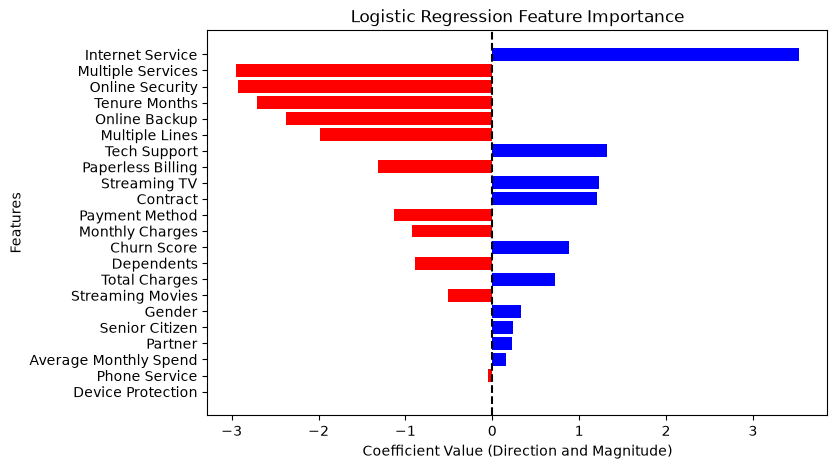

In [ ]:
plt.figure(figsize=(8, 5))
colors = ["red" if c < 0 else "blue" for c in feature_importance["Coefficients"]]
plt.barh(feature_importance["Feature"], feature_importance["Coefficients"], color=colors)
plt.axvline(x=0, color="black", linestyle="--")
plt.xlabel("Coefficient Value (Direction and Magnitude)")
plt.ylabel("Features")
plt.title("Logistic Regression Feature Importance")
plt.gca().invert_yaxis() 
plt.show()